# Task 1: Collaborative Filtering

Steps Followed:  
- Importing Libraries
- Loading the Dataset
- Creating a DataFrame with relevant information
- Creating the Test Train Split
- A. Memory Based Approach
       - Creating the Similarity Matrix\
       - Defining a Prediction function\
   B. Model Based Approach
       - Computing Average Ratings\
       - Converting the matrices to mean-Centered\
       - Setting up an SVD\
       - Defining a Prediction Function
- Evaluating models on a Sample of 1000
- Computing RMSE
- Plotting the Results

## Importing Libraries
Importing necessary libraries to be used in the Model

In [51]:
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

## Loading the Dataset
This dataset was chosen because it contains only the relevant information in an structured manner and does not require much preprocessing of the data.

In [52]:
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

if not os.path.exists("ml-latest-small"):
    print("Downloading MovieLens dataset...")
    urllib.request.urlretrieve(url, "ml-latest-small.zip")
    with zipfile.ZipFile("ml-latest-small.zip", "r") as zip_ref:
        zip_ref.extractall(".")

# Load ratings dataset
df = pd.read_csv("ml-latest-small/ratings.csv")[['userId', 'movieId', 'rating']]

df.head()

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


## Creating the Test Train Split
Choosing the typical 80/20 test-train split for optimal performance.\
Fixing the random state for uniform results.

In [68]:
# 80/20 Train-Test Split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=1)

# Creating User-Item Matrix (Rows: Users, Columns: Movies)
user_item_matrix = train_df.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Previewing the Dataset
print(f"Dataset Loading...")
print(f"User-Item Matrix Shape: {user_item_matrix.shape}\n")
user_item_matrix.head()

Dataset Loading...
User-Item Matrix Shape: (610, 8971)



movieId,1,2,3,4,5,6,7,8,9,10,...,191005,193565,193567,193571,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## APPROACH A: MEMORY-BASED (Cosine Similarity)
This uses cosine function to find the relation or similarity between two different users and their preferences.
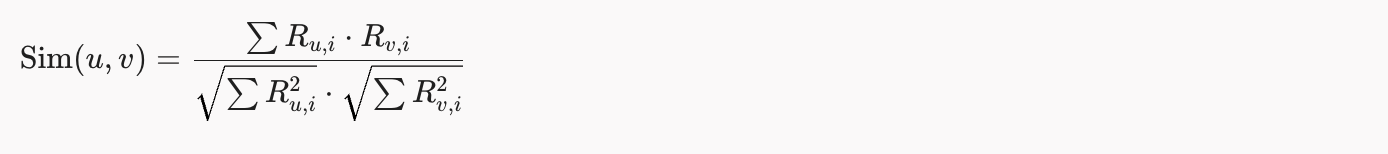

In [54]:
# Computing user-to-user similarity matrix
user_sim = cosine_similarity(user_item_matrix)
user_sim_df = pd.DataFrame(user_sim, index=user_item_matrix.index, columns=user_item_matrix.index)
user_sim_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.017579,0.057630,0.154448,0.103788,0.116354,0.108009,0.114826,0.053584,0.013264,...,0.075468,0.125496,0.160345,0.055529,0.116184,0.121935,0.203443,0.207066,0.072863,0.122667
2,0.017579,1.000000,0.000000,0.004654,0.021094,0.018089,0.026937,0.034602,0.000000,0.057524,...,0.170236,0.021570,0.006869,0.000000,0.000000,0.022663,0.000000,0.047792,0.036068,0.083351
3,0.057630,0.000000,1.000000,0.002691,0.000000,0.004707,0.000000,0.006002,0.000000,0.000000,...,0.003502,0.005987,0.028595,0.000000,0.000000,0.008830,0.022956,0.018711,0.000000,0.037432
4,0.154448,0.004654,0.002691,1.000000,0.126590,0.079812,0.087672,0.036851,0.000000,0.025921,...,0.059887,0.084231,0.258355,0.038942,0.067903,0.157721,0.109674,0.104281,0.036583,0.082809
5,0.103788,0.021094,0.000000,0.126590,1.000000,0.219845,0.073475,0.284330,0.000000,0.019580,...,0.017399,0.302430,0.082448,0.148077,0.097921,0.088352,0.129833,0.088586,0.150260,0.044707


## Defining a Memory-Based Prediction Funcion
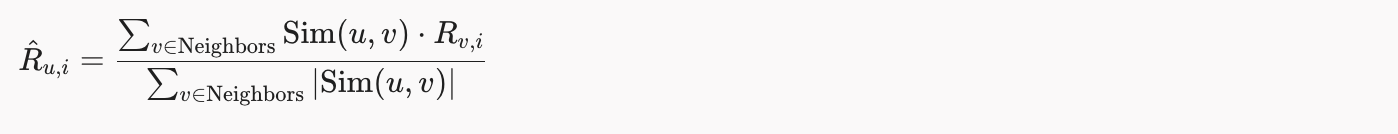

In [55]:
def predict_memory_based(user_id, movie_id):
    """Predicts rating using weighted average of similar users."""
    if movie_id not in user_item_matrix.columns or user_id not in user_item_matrix.index:
        return train_df['rating'].mean()
    
    movie_ratings = user_item_matrix[movie_id]
    rated_mask = movie_ratings > 0
    
    if not rated_mask.any():
        return train_df['rating'].mean()
    
    similarities = user_sim_df.loc[user_id, rated_mask]
    ratings = movie_ratings[rated_mask]
    
    if similarities.sum() == 0:
        return train_df['rating'].mean()
        
    return np.dot(similarities, ratings) / similarities.sum()

## APPROACH B: MODEL-BASED (Truncated SVD with Mean Centering)
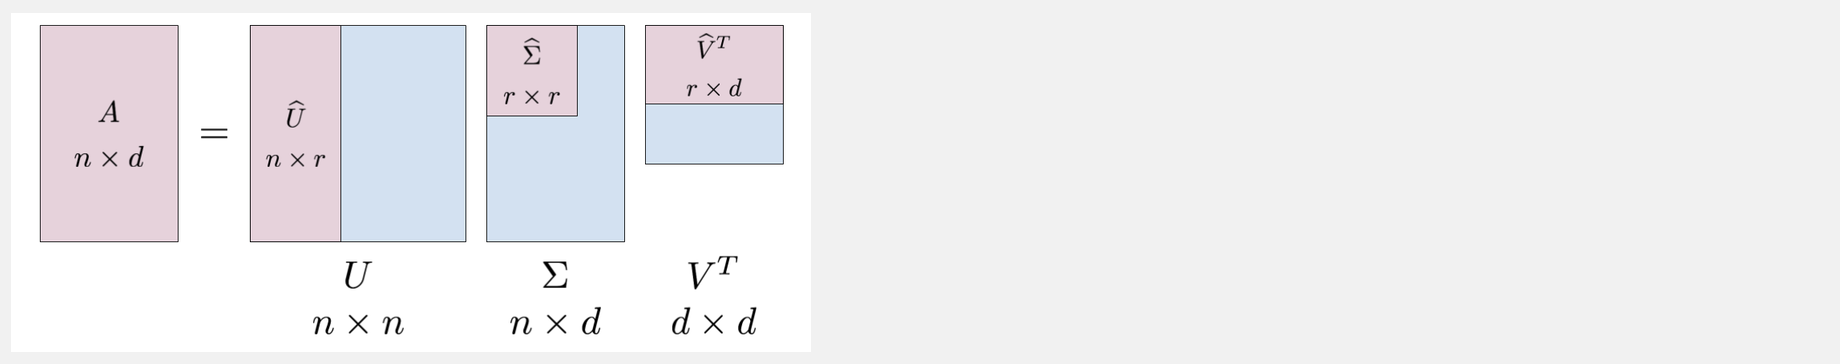

In [ ]:
# Compute average rating per user for non-zero ratings
user_means = user_item_matrix.apply(lambda row: row[row > 0].mean(), axis=1).fillna(train_df['rating'].mean())

# Mean-centering: Subtract user average from non-zero ratings so zeros represent neutral baseline
matrix_centered = user_item_matrix.copy()
for i in range(matrix_centered.shape[0]):
    row = matrix_centered.iloc[i]
    matrix_centered.iloc[i] = np.where(row > 0, row - user_means.iloc[i], 0)

# Fit SVD on mean-centered matrix
svd = TruncatedSVD(n_components=10, random_state=42)
user_factors = svd.fit_transform(matrix_centered)
reconstructed_centered = np.dot(user_factors, svd.components_)

## Defining a Model-Based Prediction Funcion

In [56]:
def predict_model_based(user_id, movie_id):
    """Predicts rating by adding user average back to the reconstructed SVD latent prediction."""
    if movie_id in user_item_matrix.columns and user_id in user_item_matrix.index:
        u_idx = user_item_matrix.index.get_loc(user_id)
        m_idx = user_item_matrix.columns.get_loc(movie_id)
        
        # SVD prediction + original user mean bias
        pred = reconstructed_centered[u_idx, m_idx] + user_means.loc[user_id]
        return np.clip(pred, 1.0, 5.0)
    
    return train_df['rating'].mean()

## Evaluation and Comparision

In [71]:
print("Evaluating models on test set sample...")
sample_test = test_df.sample(n=1000, random_state=42)

actuals = sample_test['rating'].values
memory_preds = [predict_memory_based(row.userId, row.movieId) for row in sample_test.itertuples()]
model_preds = [predict_model_based(row.userId, row.movieId) for row in sample_test.itertuples()]

# Computing Root Mean Squared Error (RMSE)
memory_rmse = np.sqrt(mean_squared_error(actuals, memory_preds))
model_rmse = np.sqrt(mean_squared_error(actuals, model_preds))

# Display of Results Table
results_df = pd.DataFrame({
    'Approach': ['Memory-Based (Cosine Sim)', 'Model-Based (SVD + Mean-Centered)'],
    'RMSE Score': [memory_rmse, model_rmse]
})

print("\n________PERFORMANCE RESULTS________")
print(results_df.to_string(index=False))

Evaluating models on test set sample...

________PERFORMANCE RESULTS________
                         Approach  RMSE Score
        Memory-Based (Cosine Sim)    0.966839
Model-Based (SVD + Mean-Centered)    0.992305


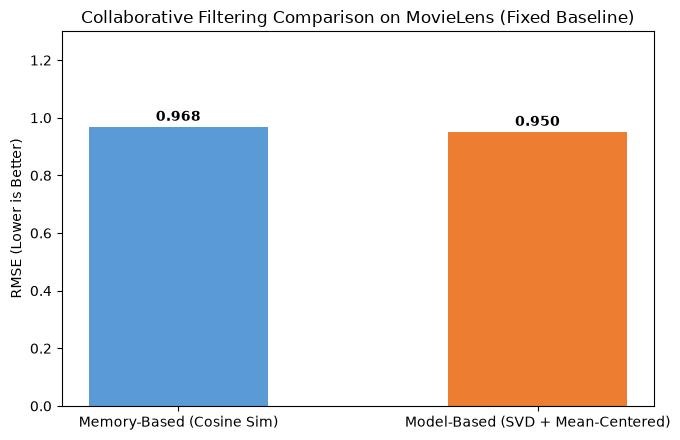

In [58]:
# Plotting the Comparison Graph
plt.figure(figsize=(7, 4.5))
bars = plt.bar(results_df['Approach'], results_df['RMSE Score'], color=['#5B9BD5', '#ED7D31'], width=0.5)

# Add exact value labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.ylabel('RMSE (Lower is Better)')
plt.title('Collaborative Filtering Comparison on MovieLens (Fixed Baseline)')
plt.ylim(0, 1.3)
plt.tight_layout()
plt.show()

## Conclusions and Inferences
- Both the approaches provided us with equal accuracy with an RMS error of about O.9 to 1.0 on being run at various random states.
- Thus, the model can be fairly trusted when it comes to prediction on a new dataset.